## Feature selection

Feature selection is the process by which you select a subset of features relevant for model construction. Feature saelection comes with several benefits, the most obvious being the improvement in performance of a machine learning algorithm. Other benefits include:

* Decrease in computational complexity: As the number of features is reduced in a model, the easier it will be to compute the parameters of your model. It will also mean a decrease in the amount of data storage required to maintain the features of your model 
* Understanding your data: In the process of feature selection, you will gain more understanding of how features relate to one another 

Now, let's look at the different types of feature selection approaches and their advantages/disadvantages: 

### Types of feature selection

Like many things in data science, there is no clear and easy answer for deciding which features to include in a model. There are, however, different strategies you can use to process features in an efficient way: 

* Domain knowledge
* Wrapper methods
* Filter methods
* Embedded methods


#### Domain knowledge   

One of the most important aspects when determining important features is the knowledge of the specific domain related to your dataset. This might mean reading past research papers that have explored similar topics or asking key stakeholders to determine what they believe the most important factors are for predicting the target variable.


#### Wrapper methods   

Wrapper methods determine the optimal subset of features using different combinations of features to train models and then calculating performance. Every subset is used to train models and then evaluated on a test set. As you might imagine, wrapper methods can end up being very computationally intensive, however, they are highly effective in determining the optimal subset. Because wrapper methods are so time-consuming, it becomes challenging to use them with large feature sets. 

<img src = "./assets/feature_selection/new_wrapper.png">

An example of a wrapper method in linear regression is **Recursive Feature Elimination**, which starts with all features included in a model and removes them one by one. After the model has had a feature removed, whichever subset of features resulted in the least statistically significant deterioration of the model fit will indicate which omitted feature is the least useful for prediction. The opposite of this process is **Forward Selection**, which undergoes the same process in reverse. It begins with a single feature and continues to add the one feature at a time that improves model performance the most.

#### Filter methods   
Filter methods are feature selection methods carried out as a pre-processing step before even running a model. Filter methods work by observing characteristics of how variables are related to one another. Depending on the model that is being used, different metrics are used to determine which features will get eliminated and which will remain. Typically, filter methods will return a "feature ranking" that will tell you how features are ordered in relation to one another. They will remove the variables that are considered redundant. It's up to the Data Scientist to determine the cut-off point at which they will keep the top $n$ features, and this $$ is usually determined through cross-validation.

<img src= "./assets/feature_selection/new_filter.png">

In the linear regression context, a common filter method is to eliminate features that are highly correlated with one another. Another method is to use a variance threshold. This sets some threshold of required variance among features in order to include them in a model. The thought process behind this is that if variables do not have a high variance, they will not change much and will therefore not have much impact on our dependent variable.


#### Embedded methods 

Embedded methods are feature selection methods that are included within the actual formulation of your machine learning algorithm. The most common kind of embedded method is regularization, in particular Lasso, because it has the capability of reducing your set of features automatically.

<img src = "./assets/feature_selection/new_embedded.png">

## Feature selection in action

Now, we're going to review the process behind performing feature selection with a dataset pertaining to diabetes. The dataset contains the independent variables age, sex, body mass index, blood pressure, and 6 different blood serum measurements. The target variable represents a quantitative measurement progression of diabetes from one year after a baseline observation. With feature selection, our goal is to find a model that is able to maintain high accuracy while not overfitting to noise.

### Process the data

To begin with, we are going to load the neccesary libraries and functions, import the data, and create a dummy variable for the variable `'SEX'`. The target variable is in the column `'Y'`.

In [ ]:
# Importing necessary libraries
import pandas as pd
import numpy as np
from sklearn import datasets, linear_model
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.linear_model import LinearRegression

# Import the data
df = pd.read_csv('data/feature_selection_methods/diabetes.tab.txt', sep='\t', lineterminator='\n')
df.head()

,AGE,SEX,BMI,BP,S1,S2,S3,S4,S5,S6,Y
0,59,2,32.1,101.0,157,93.2,38.0,4.0,4.8598,87,151
1,48,1,21.6,87.0,183,103.2,70.0,3.0,3.8918,69,75
2,72,2,30.5,93.0,156,93.6,41.0,4.0,4.6728,85,141
3,24,1,25.3,84.0,198,131.4,40.0,5.0,4.8903,89,206
4,50,1,23.0,101.0,192,125.4,52.0,4.0,4.2905,80,135


In [ ]:
# Obtain the target and features from the DataFrame
target = df['Y']
features = df.drop(columns='Y')

In [ ]:
# Create dummy variable for sex
features['female'] = pd.get_dummies(features['SEX'], drop_first=True)
features.drop(columns=['SEX'], inplace=True)
features.head()

,AGE,BMI,BP,S1,S2,S3,S4,S5,S6,female
0,59,32.1,101.0,157,93.2,38.0,4.0,4.8598,87,1
1,48,21.6,87.0,183,103.2,70.0,3.0,3.8918,69,0
2,72,30.5,93.0,156,93.6,41.0,4.0,4.6728,85,1
3,24,25.3,84.0,198,131.4,40.0,5.0,4.8903,89,0
4,50,23.0,101.0,192,125.4,52.0,4.0,4.2905,80,0


For both regularization (an embedded method) and various filters, it is important to standardize the data. This next cell is fitting a `StandardScaler` from `sklearn` to the data.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Split the data
X_train, X_test, y_train, y_test = train_test_split(features, target, random_state=20, test_size=0.2)

# Initialize the scaler
scaler = StandardScaler()

# Scale every feature except the binary column - female
transformed_training_features = scaler.fit_transform(X_train.iloc[:,:-1])
transformed_testing_features = scaler.transform(X_test.iloc[:,:-1])

# Convert the scaled features into a DataFrame
X_train_transformed = pd.DataFrame(scaler.transform(X_train.iloc[:,:-1]), 
                                   columns=X_train.columns[:-1], 
                                   index=X_train.index)
X_train_transformed['female'] = X_train['female']

X_test_transformed = pd.DataFrame(scaler.transform(X_test.iloc[:,:-1]), 
                                  columns=X_train.columns[:-1], 
                                  index=X_test.index)
X_test_transformed['female'] = X_test['female']

Before we perform feature selection, we should see how well the baseline model performs. Because we are going to be running many different models here, we have created a function to ensure that we are following the D.R.Y. principle.

In [ ]:
def run_model(model, X_train, X_test, y_train, y_test):
    
    print('Training R^2 :', model.score(X_train, y_train))
    y_pred_train = model.predict(X_train)
    print('Training Root Mean Square Error', np.sqrt(metrics.mean_squared_error(y_train, y_pred_train)))
    print('\n----------------\n')
    print('Testing R^2 :', model.score(X_test, y_test))
    y_pred_test = model.predict(X_test)
    print('Testing Root Mean Square Error', np.sqrt(metrics.mean_squared_error(y_test, y_pred_test)))

In [ ]:
lm = LinearRegression()
lm.fit(X_train_transformed, y_train)
run_model(lm, X_train_transformed, X_test_transformed, y_train, y_test)

Training R^2 : 0.5371947100976313
Training Root Mean Square Error 52.21977472848369

----------------

Testing R^2 : 0.41797754631986483
Testing Root Mean Square Error 58.83589708889503


The model has not performed exceptionally well here, so we can try adding some additional features. Let's go ahead and add a polynomial degree of up to 3.

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, interaction_only=False, include_bias=False)
X_poly_train = pd.DataFrame(poly.fit_transform(X_train_transformed), columns=poly.get_feature_names(features.columns))
X_poly_test = pd.DataFrame(poly.transform(X_test_transformed), columns=poly.get_feature_names(features.columns))
X_poly_train.head()

,AGE,BMI,BP,S1,S2,S3,S4,S5,S6,female,...,S4^2,S4 S5,S4 S6,S4 female,S5^2,S5 S6,S5 female,S6^2,S6 female,female^2
0,-0.433522,-0.967597,-2.067847,-1.623215,-1.280312,-0.347527,-0.852832,-1.095555,-1.006077,0.0,...,0.727322,0.934324,0.858015,-0.000000,1.200240,1.102213,-0.000000,1.012192,-0.000000,0.0
1,1.117754,-0.516691,1.142458,-0.168101,-0.129601,-0.424950,-0.083651,0.543382,-0.831901,1.0,...,0.006998,-0.045455,0.069589,-0.083651,0.295264,-0.452040,0.543382,0.692060,-0.831901,1.0
2,1.350445,1.850570,1.427819,0.413945,0.764667,-1.044334,1.454710,0.597504,1.519478,1.0,...,2.116182,0.869195,2.210400,1.454710,0.357011,0.907894,0.597504,2.308813,1.519478,1.0
3,-0.511086,-1.373413,-1.711146,-0.837453,-1.148802,1.278358,-1.622013,-0.796071,-0.918989,0.0,...,2.630925,1.291237,1.490612,-0.000000,0.633729,0.731581,-0.000000,0.844541,-0.000000,0.0
4,-0.743778,0.114579,-0.141664,-1.565010,-1.339491,-0.115257,-0.852832,-0.970101,0.648597,1.0,...,0.727322,0.827333,-0.553144,-0.852832,0.941095,-0.629204,-0.970101,0.420678,0.648597,1.0


As you can see, we now have 65 total columns! You can imagine that this model will greatly overfit to the data. Let's try it out with our training and test set.

In [ ]:
lr_poly = LinearRegression()
lr_poly.fit(X_poly_train, y_train)

run_model(lr_poly, X_poly_train, X_poly_test, y_train, y_test)

Training R^2 : 0.6237424326763874
Training Root Mean Square Error 47.084553723292245

----------------

Testing R^2 : 0.3688694444251718
Testing Root Mean Square Error 61.26777562691541


Clearly, the model has fit very well to the training data, but it has fit to a lot of noise. The testing $R^{2}$ is worse than the simple model we fit previously! It's time to get rid of some features to see if this improves the model.

## Filter methods  

Let's begin by trying out some filter methods for feature selection. The benefit of filter methods is that they can provide us with some useful visualizations for helping us gain an understanding about the characteristics of our data. To begin with, let's use a simple variance threshold to eliminate the features with low variance.

In [ ]:
from sklearn.feature_selection import VarianceThreshold

threshold_ranges = np.linspace(0, 2, num=6)

for thresh in threshold_ranges:
    print(thresh)
    selector = VarianceThreshold(thresh)
    reduced_feature_train = selector.fit_transform(X_poly_train)
    reduced_feature_test = selector.transform(X_poly_test)
    lr = LinearRegression()
    lr.fit(reduced_feature_train, y_train)
    run_model(lr, reduced_feature_train, reduced_feature_test, y_train, y_test)
    print('--------------------------------------------------------------------')

0.0
Training R^2 : 0.623742432676387
Training Root Mean Square Error 47.08455372329227

----------------

Testing R^2 : 0.36886944442517433
Testing Root Mean Square Error 61.26777562691529
--------------------------------------------------------------------
0.4
Training R^2 : 0.6035018897144957
Training Root Mean Square Error 48.33440733222434

----------------

Testing R^2 : 0.358080196285809
Testing Root Mean Square Error 61.789246194094176
--------------------------------------------------------------------
0.8
Training R^2 : 0.5894227238666293
Training Root Mean Square Error 49.18506972762005

----------------

Testing R^2 : 0.3640169603035095
Testing Root Mean Square Error 61.502855071460274
--------------------------------------------------------------------
1.2000000000000002
Training R^2 : 0.1991536009695497
Training Root Mean Square Error 68.69267841228015

----------------

Testing R^2 : 0.03625491787410018
Testing Root Mean Square Error 75.71006122152008
--------------------

Well, that did not seem to eliminate the features very well. It only does a little better than the base polynomial.

In [ ]:
from sklearn.feature_selection import f_regression, mutual_info_regression, SelectKBest
selector = SelectKBest(score_func=f_regression)
X_k_best_train = selector.fit_transform(X_poly_train, y_train)
X_k_best_test= selector.transform(X_poly_test)
lr = LinearRegression()
lr.fit(X_k_best_train ,y_train)
run_model(lr,X_k_best_train,X_k_best_test,y_train,y_test)

Training R^2 : 0.5229185029521006
Training Root Mean Square Error 53.01907218972858

----------------

Testing R^2 : 0.42499888052723567
Testing Root Mean Square Error 58.4799314703427


In [ ]:
selector = SelectKBest(score_func=mutual_info_regression)
X_k_best_train = selector.fit_transform(X_poly_train, y_train)
X_k_best_test= selector.transform(X_poly_test)
lr = LinearRegression()
lr.fit(X_k_best_train ,y_train)
run_model(lr,X_k_best_train,X_k_best_test,y_train,y_test)

Training R^2 : 0.48788560532499714
Training Root Mean Square Error 54.93123060353359

----------------

Testing R^2 : 0.39166279490049805
Testing Root Mean Square Error 60.15125584031384


## Wrapper methods

Now let's use Recursive Feature elimination (RFE) to try out a wrapper method. You'll notice that scikit-learn has a built in `RFECV()` function, which automatically determines the optimal number of features to keep when it is run based off the estimator that is passed into it. Here it is in action:

In [ ]:
from sklearn.feature_selection import RFE, RFECV
from sklearn.linear_model import LinearRegression

rfe = RFECV(LinearRegression(),cv=5)
X_rfe_train = rfe.fit_transform(X_poly_train, y_train)
X_rfe_test = rfe.transform(X_poly_test)
lm = LinearRegression().fit(X_rfe_train, y_train)
run_model(lm, X_rfe_train, X_rfe_test, y_train, y_test)
print ('The optimal number of features is: ', rfe.n_features_)

Training R^2 : 0.37930327292162724
Training Root Mean Square Error 60.474956480110215

----------------

Testing R^2 : 0.37417761375281067
Testing Root Mean Square Error 61.009583057744294
The optimal number of features is:  10


With Recursive Feature Elimination, we went from an $R^2$ score of 0.368 to 0.374 (a tiny bit better). Let's see if we can improve upon these results even more by trying embedded methods.

## Embedded methods  

To compare to our other methods, we will use Lasso as the embedded method of feature selection. Luckily for us, sklearn has a built-in method to help us find the optimal features! It performs cross validation to determine the correct regularization parameter (how much to penalize our function).

In [ ]:
from sklearn.linear_model import LassoCV
lasso = LassoCV(max_iter=100000, cv=5)
lasso.fit(X_train_transformed, y_train)
run_model(lasso,X_train_transformed, X_test_transformed, y_train, y_test)
print('The optimal alpha for the Lasso Regression is: ', lasso.alpha_)

Training R^2 : 0.535154465585244
Training Root Mean Square Error 52.33475174961373

----------------

Testing R^2 : 0.4267044232634858
Testing Root Mean Square Error 58.39313677555575
The optimal alpha for the Lasso Regression is:  0.23254844944953376


Let's compare this to a model with all of the polynomial features included.

In [ ]:
lasso2 = LassoCV(max_iter=100000, cv=5)

lasso2.fit(X_poly_train, y_train)
run_model(lasso2, X_poly_train, X_poly_test, y_train, y_test)
print('The optimal alpha for the Lasso Regression is: ', lasso2.alpha_)

Training R^2 : 0.5635320505309954
Training Root Mean Square Error 50.71214913665365

----------------

Testing R^2 : 0.43065954589620015
Testing Root Mean Square Error 58.191363260874226
The optimal alpha for the Lasso Regression is:  1.7591437388826368


As we can see, the regularization had minimal effect on the performance of the model, but it did improve the RMSE for the test set ever so slightly! There are no set steps someone should take in order to determine the optimal feature set. In fact, now there are automated machine learning pipelines that will determine the optimal subset of features for a given problem. One of the most important and often overlooked methods of feature selection is using domain knowledge about a given area to either eliminate features or create new ones.

__Additional Resources__: 

- [Feature Selection](https://www.researchgate.net/profile/Amparo_Alonso-Betanzos/publication/221252792_Filter_Methods_for_Feature_Selection_-_A_Comparative_Study/links/543fd9ec0cf21227a11b8e05.pdf)


- [An Introduction to Variable and Feature Selection](http://www.jmlr.org/papers/volume3/guyon03a/guyon03a.pdf)

## AIC

The formula for the AIC, invented by Hirotugu Akaike in 1973 and short for "Akaike's Information Criterion" is given by:

#### $$ \text{AIC} = -2\ln(\hat{L}) + 2k $$

Where:
* $k$ : length of the parameter space (i.e. the number of features)
* $\hat{L}$ : the maximum value of the likelihood function for the model

Another way to phrase the equation is:

$$ \text{AIC(model)} =  - 2 * \text{log-likelihood(model)} + 2 * \text{length of the parameter space} $$

The AIC is generally used to compare each candidate model. The nice thing about the AIC is that for every model that uses Maximum Likelihood Estimation, the log-likelihood is automatically computed, and as a consequence, the AIC is very easy to calculate.

The AIC acts as a penalized log-likelihood criterion, giving a balance between a good fit
(high value of log-likelihood) and complexity (complex models are penalized more than fairly simple ones). The AIC is unbounded so it can take any type of value, but the bottom line is that when comparing models, the model with the **lowest** AIC should be selected.

Note that directly comparing the values of log-likelihood maxima for different models (without including the penalty) is not good enough for model comparison because including more parameters in a model will *always* give rise to an increased value of the maximum likelihood. Due to that reason, searching for the model with maximal log-likelihood
would always lead to the model with the most parameters. The AIC balances this by penalizing for the number of parameters, hence searching for models with few parameters but fitting the data well.

In Python, the AIC is built into `statsmodels` and in `sklearn` (such as `LassoLarsIC`, which you'll use in the upcoming lab).

## BIC

The BIC (Bayesian Information Criterion) is very similar to the AIC and emerged as a Bayesian response to the AIC, but can be used for the exact same purposes. The idea is to select the candidate model with the highest probability
given the data. 
This idea can be formalized inside a Bayesian framework, involving prior probabilities on candidate models along with prior densities on all parameters in the models. The penalty is slightly changed and depends on the number of rows in the dataset:

$$ \text{BIC} = - 2\ln(\hat{L}) + \ln(n) * k $$

where:

* $\hat{L}$ and $k$ are the same as in AIC
* $n$ : the number of data points (the sample size)

Another way to phrase the equation is:

$$ \text{BIC(model)} = -2 * \text{log-likelihood(model)} + \text{log(number of observations)} * \text{(length of the parameter space)} $$

Like the AIC, the **lower** your BIC, the better your model is performing.

## Uses of AIC and BIC

- Performing feature selection: comparing models with only a few variables and more variables, computing the AIC/BIC and select the features that generated the lowest AIC or BIC
- Similarly, selecting or not selecting interactions/polynomial features depending on whether or not the AIC/BIC decreases when adding them in
- Computing the AIC and BIC for several values of the regularization parameter in Ridge/Lasso models and selecting the best regularization parameter, and many more!

## Let's get started!

Import all the necessary packages.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.preprocessing import scale

from sklearn.datasets import load_boston

## Look at a baseline boston housing data model

- Import the Boston housing dataset 
- Split the data into target (`y`) and predictors (`X`) -- ensure these both are DataFrames 
- Scale all the predictors using `scale`. Convert these scaled features into a DataFrame 
- Build at a baseline model using *scaled variables* as predictors. Use 5-fold cross-validation (set `random_state` to 1) and use the $R^2$ score to evaluate the model

In [ ]:
boston = load_boston()

y = pd.DataFrame(boston.target, columns=['target'])
X = pd.DataFrame(boston.data, columns=boston.feature_names)

X_scaled = scale(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

all_data = pd.concat([y, X_scaled], axis=1)

In [ ]:
all_data.head(2)

,target,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,24.0,-0.419782,0.284830,-1.287909,-0.272599,-0.144217,0.413672,-0.120013,0.140214,-0.982843,-0.666608,-1.459000,0.441052,-1.075562
1,21.6,-0.417339,-0.487722,-0.593381,-0.272599,-0.740262,0.194274,0.367166,0.557160,-0.867883,-0.987329,-0.303094,0.441052,-0.492439


In [ ]:
regression = LinearRegression()

crossvalidation = KFold(n_splits=5, shuffle=True, random_state=1)
baseline = np.mean(cross_val_score(regression, X_scaled, y, scoring='r2', cv=crossvalidation))
baseline

0.7176778617934925

## Include interactions

Look at all the possible combinations of variables for interactions by adding interactions one by one to the baseline model. Next, evaluate that model using 5-fold cross-validation and store the $R^2$ to compare it with the baseline model.

Print the 7 most important interactions.

In [ ]:
from itertools import combinations
combinations = list(combinations(boston.feature_names, 2))

interactions = []
data = X_scaled.copy()
for comb in combinations:
    data['interaction'] = data[comb[0]] * data[comb[1]]
    score = np.mean(cross_val_score(regression, data, y, scoring='r2', cv=crossvalidation))
    if score > baseline: interactions.append((comb[0], comb[1], round(score, 3)))
            
print('Top 7 interactions: %s' %sorted(interactions, key=lambda inter: inter[2], reverse=True)[:7])

Top 7 interactions: [('RM', 'LSTAT', 0.783), ('RM', 'TAX', 0.775), ('RM', 'RAD', 0.77), ('RM', 'PTRATIO', 0.764), ('INDUS', 'RM', 0.757), ('NOX', 'RM', 0.746), ('RM', 'AGE', 0.742)]


Write code to include the 7 most important interactions in your data set by adding 7 columns. Name the columns "var1_var2" with var1 and var2 the two variables in the interaction.

In [ ]:
df_inter = X_scaled.copy()
ls_interactions = sorted(interactions, key=lambda inter: inter[2], reverse=True)[:7]
for inter in ls_interactions:
    df_inter[inter[0] + '_' + inter[1]] = X[inter[0]] * X[inter[1]]

## Include polynomials

Try polynomials of degrees 2, 3, and 4 for each variable, in a similar way you did for interactions (by looking at your baseline model and seeing how $R^2$ increases). Do understand that when going for a polynomial of 4, the particular column is raised to the power of 2 and 3 as well in other terms. We only want to include "pure" polynomials, so make sure no interactions are included. We want the result to return a list that contain tuples of the form:

`(var_name, degree, R2)`, so eg. `('DIS', 3, 0.732)`

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
polynomials = []
for col in X.columns:
    for degree in [2, 3, 4]:
        data = X_scaled.copy()
        poly = PolynomialFeatures(degree, include_bias=False)
        X_transformed = poly.fit_transform(X[[col]])
        data = pd.concat([data.drop(col, axis=1),pd.DataFrame(X_transformed)], axis=1)
        score = np.mean(cross_val_score(regression, data, y, scoring='r2', cv=crossvalidation))
        if score > baseline: polynomials.append((col, degree, round(score, 3)))
print('Top 10 polynomials: %s' %sorted(polynomials, key=lambda poly: poly[2], reverse=True)[:10])

Top 10 polynomials: [('RM', 4, 0.8), ('RM', 2, 0.782), ('LSTAT', 4, 0.782), ('RM', 3, 0.781), ('LSTAT', 3, 0.774), ('LSTAT', 2, 0.772), ('DIS', 3, 0.737), ('DIS', 2, 0.732), ('DIS', 4, 0.731), ('TAX', 4, 0.724)]


For each variable, print out the maximum R2 possible when including Polynomials.

In [ ]:
polynom = pd.DataFrame(polynomials)
polynom.groupby([0], sort=False)[2].max()

0
ZN         0.723
INDUS      0.723
NOX        0.721
RM         0.800
AGE        0.722
DIS        0.737
RAD        0.720
TAX        0.724
PTRATIO    0.721
B          0.720
LSTAT      0.782
Name: 2, dtype: float64

Which two variables seem to benefit most from adding polynomial terms?

Add Polynomials for the two features that seem to benefit the most, as in have the best R squared compared to the baseline model. For each of the two features, raise to the Polynomial that generates the best result. Make sure to start from the data set `df_inter` so the final data set has both interactions and polynomials in the model.

In [ ]:
for col in ['RM', 'LSTAT']:
    poly = PolynomialFeatures(4, include_bias=False)
    X_transformed = poly.fit_transform(X[[col]])
    colnames= [col, col + '_' + '2',  col + '_' + '3', col + '_' + '4']
    df_inter = pd.concat([df_inter.drop(col, axis=1), pd.DataFrame(X_transformed, columns=colnames)], axis=1)

Check out your final data set and make sure that your interaction terms as well as your polynomial terms are included.

In [ ]:
df_inter.head()

,CRIM,ZN,INDUS,CHAS,NOX,AGE,DIS,RAD,TAX,PTRATIO,...,NOX_RM,RM_AGE,RM,RM_2,RM_3,RM_4,LSTAT,LSTAT_2,LSTAT_3,LSTAT_4
0,-0.419782,0.284830,-1.287909,-0.272599,-0.144217,-0.120013,0.140214,-0.982843,-0.666608,-1.459000,...,3.537350,428.6900,6.575,43.230625,284.241359,1868.886938,4.98,24.8004,123.505992,615.059840
1,-0.417339,-0.487722,-0.593381,-0.272599,-0.740262,0.367166,0.557160,-0.867883,-0.987329,-0.303094,...,3.011449,506.6169,6.421,41.229241,264.732956,1699.850313,9.14,83.5396,763.551944,6978.864768
2,-0.417342,-0.487722,-0.593381,-0.272599,-0.740262,-0.265812,0.557160,-0.867883,-0.987329,-0.303094,...,3.369765,439.0035,7.185,51.624225,370.920057,2665.060607,4.03,16.2409,65.450827,263.766833
3,-0.416750,-0.487722,-1.306878,-0.272599,-0.835284,-0.809889,1.077737,-0.752922,-1.106115,0.113032,...,3.205084,320.5084,6.998,48.972004,342.706084,2398.257176,2.94,8.6436,25.412184,74.711821
4,-0.412482,-0.487722,-1.306878,-0.272599,-0.835284,-0.511180,1.077737,-0.752922,-1.106115,0.113032,...,3.273326,387.3674,7.147,51.079609,365.065966,2609.126456,5.33,28.4089,151.419437,807.065599


## Full model R-squared

Check out the R-squared of the full model.

In [ ]:
full_model = np.mean(cross_val_score(regression, df_inter, y, scoring='r2', cv=crossvalidation))
full_model

0.8061549447223412

## Find the best Lasso regularization parameter

You learned that when using Lasso regularization, your coefficients shrink to 0 when using a higher regularization parameter. Now the question is which value we should choose for the regularization parameter. 

This is where the AIC and BIC come in handy! We'll use both criteria in what follows and perform cross-validation to select an optimal value of the regularization parameter $alpha$ of the Lasso estimator.

Read the page here: https://scikit-learn.org/stable/auto_examples/linear_model/plot_lasso_model_selection.html and create a similar plot as the first one listed on the page.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LassoCV, LassoLarsCV, LassoLarsIC

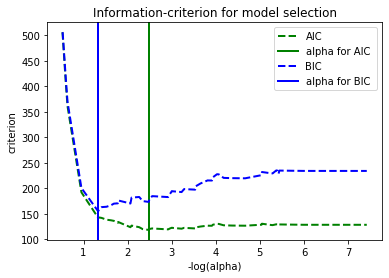

In [ ]:
model_bic = LassoLarsIC(criterion='bic')
model_bic.fit(df_inter, y)
alpha_bic_ = model_bic.alpha_

model_aic = LassoLarsIC(criterion='aic')
model_aic.fit(df_inter, y)
alpha_aic_ = model_aic.alpha_


def plot_ic_criterion(model, name, color):
    alpha_ = model.alpha_
    alphas_ = model.alphas_
    criterion_ = model.criterion_
    plt.plot(-np.log10(alphas_), criterion_, '--', color=color, linewidth=2, label= name)
    plt.axvline(-np.log10(alpha_), color=color, linewidth=2,
                label='alpha for %s ' % name)
    plt.xlabel('-log(alpha)')
    plt.ylabel('criterion')

plt.figure()
plot_ic_criterion(model_aic, 'AIC', 'green')
plot_ic_criterion(model_bic, 'BIC', 'blue')
plt.legend()
plt.title('Information-criterion for model selection');

## Analyze the final result

Finally, use the best value for the regularization parameter according to AIC and BIC, and compare R-squared and MSE using train-test split. Compare with the baseline model.

In [ ]:
from sklearn.metrics import mean_squared_error, mean_squared_log_error
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso

In [ ]:
# Split X_scaled and y into training and test sets <- original 
# Set random_state to 1
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, random_state=1) 

# Code for baseline model
linreg_all = LinearRegression()
linreg_all.fit(X_train, y_train)

# Print R2 and MSE
print('Training r^2:', linreg_all.score(X_train, y_train))
print('Test r^2:', linreg_all.score(X_test, y_test))
print('Training MSE:', mean_squared_error(y_train, linreg_all.predict(X_train)))
print('Test MSE:', mean_squared_error(y_test, linreg_all.predict(X_test)))

Training r^2: 0.7168057552393374
Test r^2: 0.7789410172622857
Training MSE: 22.477983821877896
Test MSE: 21.897765396049497


In [ ]:
# Split df_inter and y into training and test sets
# Set random_state to 1
X_train, X_test, y_train, y_test = train_test_split(df_inter, y, random_state=1)

# Code for lasso with alpha from AIC
lasso = Lasso(alpha= model_aic.alpha_) 
lasso.fit(X_train, y_train)

# Print R2 and MSE
print('Training r^2:', lasso.score(X_train, y_train))
print('Test r^2:', lasso.score(X_test, y_test))
print('Training MSE:', mean_squared_error(y_train, lasso.predict(X_train)))
print('Test MSE:', mean_squared_error(y_test, lasso.predict(X_test)))


Training r^2: 0.8155720603121368
Test r^2: 0.8648860563031302
Training MSE: 14.638603436696343
Test MSE: 13.384181018871216


In [ ]:
# Code for lasso with alpha from BIC
lasso = None


# Print R2 and MSE


## Level up (Optional)

### Create a Lasso path

From this section, you know that when using lasso, more parameters shrink to zero as your regularization parameter goes up. In Scikit-learn there is a function `lasso_path()` which visualizes the shrinkage of the coefficients while $alpha$ changes. Try this out yourself!

https://scikit-learn.org/stable/auto_examples/linear_model/plot_lasso_coordinate_descent_path.html#sphx-glr-auto-examples-linear-model-plot-lasso-coordinate-descent-path-py

### AIC and BIC for subset selection
This notebook shows how you can use AIC and BIC purely for feature selection. Try this code out on our Boston housing data!

https://xavierbourretsicotte.github.io/subset_selection.html